# 📈 Quantitative Strategy Evaluation and Comparison

**By: Paranjita Debnath**

---

## 🎯 What This Project Does

In this notebook, I compare **3 simple trading strategies** to see which one performs best:

1. **Buy & Hold** — Buy a stock and never sell it
2. **Momentum Strategy** — Buy when recent returns are positive
3. **SMA Crossover** — Trade based on moving average signals

I use simulated stock prices (so we don't need an API key) and measure each strategy with:
- Sharpe Ratio (risk-adjusted performance)
- Total and annual returns
- Maximum Drawdown (worst loss from peak)
- Correlation between strategies

---

### Libraries Used
- `pandas` — for working with data tables
- `numpy` — for math calculations
- `matplotlib` — for making charts
- `seaborn` — for prettier charts

In [1]:
# ============================================================
# CELL 1: Import libraries
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os

# Create folders for saving output
os.makedirs('plots', exist_ok=True)
os.makedirs('data', exist_ok=True)

# Set a nice style for all charts
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Set random seed so we get the same results every time
np.random.seed(42)

print('Libraries loaded! ✓')

Libraries loaded! ✓


---
## 📦 Step 1: Create Simulated Stock Data

Since we don't have access to real market data here, we'll **simulate** stock prices using a simple **random walk** model.

The idea is simple: each day's price = yesterday's price × (1 + small random return).

This is called **Geometric Brownian Motion (GBM)** — the same model used in the famous Black-Scholes formula!

In [2]:
# ============================================================
# CELL 2: Simulate 5 years of daily stock prices
# ============================================================

n_days = 1260  # about 5 years of trading days (252 days/year)
dates = pd.date_range(start='2019-01-01', periods=n_days, freq='B')  # 'B' = business days

def simulate_stock(start_price, annual_return, annual_vol, n_days, seed=0):
    """
    Simulate daily stock prices.
    
    Parameters:
    - start_price : the starting price of the stock
    - annual_return: expected yearly return (e.g., 0.12 = 12%)
    - annual_vol   : yearly volatility / risk (e.g., 0.20 = 20%)
    - n_days       : how many days to simulate
    - seed         : random seed for reproducibility
    """
    np.random.seed(seed)
    
    # Convert annual numbers to daily (252 trading days in a year)
    daily_return = annual_return / 252
    daily_vol    = annual_vol    / np.sqrt(252)
    
    # Generate random daily returns: drift + random noise
    returns = np.random.normal(daily_return, daily_vol, n_days)
    
    # Build the price series by compounding the returns
    prices = start_price * np.cumprod(1 + returns)
    
    return prices

# Simulate three different stocks with different characteristics
price_A = simulate_stock(100, 0.12, 0.20, n_days, seed=1)  # moderate growth, moderate risk
price_B = simulate_stock(50,  0.08, 0.15, n_days, seed=2)  # slow growth, low risk
price_C = simulate_stock(75,  0.15, 0.30, n_days, seed=3)  # high growth, high risk

# Put everything in a DataFrame (like an Excel spreadsheet in Python)
prices = pd.DataFrame({
    'Stock_A': price_A,
    'Stock_B': price_B,
    'Stock_C': price_C
}, index=dates)

# Save to a CSV file
prices.to_csv('data/simulated_prices.csv')

# Preview the data
print(f'Shape: {prices.shape} (rows x columns)')
print(f'Date range: {prices.index[0].date()} to {prices.index[-1].date()}')
print()
prices.head()

Shape: (1260, 3) (rows x columns)
Date range: 2019-01-01 to 2023-10-30



,Stock_A,Stock_B,Stock_C
2019-01-01,102.094102,49.818973,77.579785
2019-01-02,101.355837,49.808302,78.265940
2019-01-03,100.729646,48.818725,78.455255
2019-01-04,99.415936,49.590870,75.739019
2019-01-07,100.547220,48.766228,75.387067


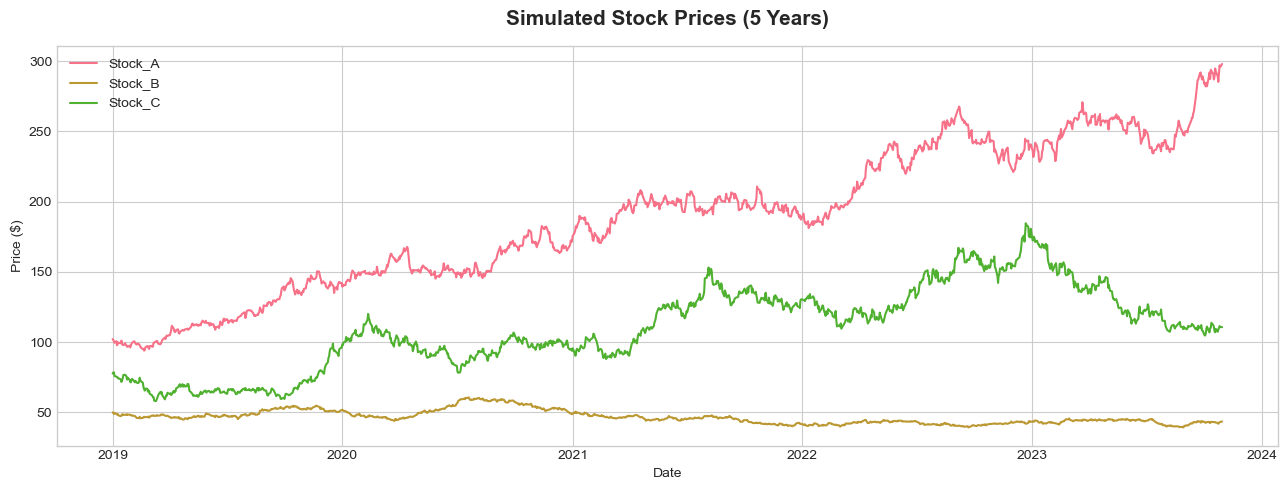

Note: These are SIMULATED prices — not real market data.


In [3]:
# ============================================================
# CELL 3: Plot the simulated stock prices
# ============================================================

fig, ax = plt.subplots(figsize=(13, 5))

for col in prices.columns:
    ax.plot(prices.index, prices[col], label=col, linewidth=1.5)

ax.set_title('Simulated Stock Prices (5 Years)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()

plt.tight_layout()
plt.savefig('plots/01_stock_prices.png', dpi=150, bbox_inches='tight')
plt.show()

print('Note: These are SIMULATED prices — not real market data.')

---
## 📊 Step 2: Calculate Daily Returns

Before building strategies, we need to convert prices into **daily returns**.

```
Daily Return = (Today's Price - Yesterday's Price) / Yesterday's Price
```

Returns are more useful than raw prices because they let us compare strategies fairly.

In [4]:
# ============================================================
# CELL 4: Calculate daily percentage returns
# ============================================================

# pct_change() does: (today - yesterday) / yesterday
daily_returns = prices.pct_change().dropna()  # .dropna() removes the first row (NaN)

print('Daily Returns Summary:')
print('-' * 40)
print(daily_returns.describe().round(4))

Daily Returns Summary:
----------------------------------------
         Stock_A    Stock_B    Stock_C
count  1259.0000  1259.0000  1259.0000
mean      0.0009    -0.0001     0.0005
std       0.0124     0.0094     0.0190
min      -0.0380    -0.0248    -0.0566
25%      -0.0071    -0.0063    -0.0122
50%       0.0008    -0.0003     0.0006
75%       0.0090     0.0059     0.0135
max       0.0503     0.0391     0.0706


---
## 🧠 Step 3: Build the 3 Trading Strategies

We'll focus on **Stock A** and apply three strategies to it.

### Strategy 1: Buy & Hold
- Buy on day 1, hold until the end — the simplest possible strategy

### Strategy 2: Momentum
- Look at the average return over the past 20 days
- If positive → buy (go long)
- If negative → go to cash (0% return)

### Strategy 3: SMA Crossover
- Calculate a **fast** moving average (10-day) and **slow** moving average (50-day)
- When fast > slow → buy signal
- When fast < slow → sell and sit in cash

In [5]:
# ============================================================
# CELL 5: Implement the 3 strategies
# ============================================================

stock = prices['Stock_A'].copy()    # we work with Stock A
ret   = daily_returns['Stock_A'].copy()

# ----- STRATEGY 1: Buy and Hold -----
# Just hold the stock every single day — no decisions needed!
bh_returns = ret.copy()
print('Strategy 1 (Buy & Hold): Just hold the stock every day.')

# ----- STRATEGY 2: Momentum -----
# We look back 20 days. If the average return is positive, we buy.
lookback = 20  # days to look back
momentum_signal  = ret.rolling(lookback).mean()        # average of past 20 returns
momentum_returns = ret * (momentum_signal > 0).shift(1) # apply signal from previous day
momentum_returns = momentum_returns.dropna()
print(f'Strategy 2 (Momentum): Buy when avg {lookback}-day return > 0.')

# ----- STRATEGY 3: SMA Crossover -----
# Compare a fast moving average to a slow moving average
fast_window = 10  # fast moving average looks at last 10 days
slow_window = 50  # slow moving average looks at last 50 days

fast_ma = stock.rolling(fast_window).mean()  # short-term trend
slow_ma = stock.rolling(slow_window).mean()  # long-term trend

# When fast MA is above slow MA → signal to buy (value = 1)
# When fast MA is below slow MA → stay in cash (value = 0)
sma_signal   = (fast_ma > slow_ma).astype(int)
sma_returns  = ret * sma_signal.shift(1)  # trade based on yesterday's signal
sma_returns  = sma_returns.dropna()
print(f'Strategy 3 (SMA Crossover): Buy when {fast_window}-day MA > {slow_window}-day MA.')

# Align all strategies to common dates
common_index = (bh_returns.index
                .intersection(momentum_returns.index)
                .intersection(sma_returns.index))

bh_returns       = bh_returns.loc[common_index]
momentum_returns = momentum_returns.loc[common_index]
sma_returns      = sma_returns.loc[common_index]

# Combine all 3 into one DataFrame
all_returns = pd.DataFrame({
    'Buy & Hold'    : bh_returns,
    'Momentum'      : momentum_returns,
    'SMA Crossover' : sma_returns
})

print(f'\nAll strategies aligned: {len(all_returns)} trading days')

Strategy 1 (Buy & Hold): Just hold the stock every day.
Strategy 2 (Momentum): Buy when avg 20-day return > 0.
Strategy 3 (SMA Crossover): Buy when 10-day MA > 50-day MA.

All strategies aligned: 1258 trading days


---
## 📐 Step 4: Performance Metrics

Now we calculate the key metrics to evaluate each strategy:

| Metric | Formula | Meaning |
|--------|---------|----------|
| **Sharpe Ratio** | (Avg Return - Risk Free Rate) / Std Dev | Risk-adjusted return |
| **Total Return** | Final Value / Start Value - 1 | How much you made overall |
| **Annual Return** | Total Return ^ (1/years) - 1 | Yearly average return |
| **Volatility** | Std Dev of returns × √252 | How much returns fluctuate |
| **Max Drawdown** | Biggest peak-to-valley drop | Worst loss you'd have experienced |

In [6]:
# ============================================================
# CELL 6: Define metric calculation functions
# ============================================================

def sharpe_ratio(returns, risk_free_rate=0.02):
    """
    Sharpe Ratio measures how much return we get per unit of risk.
    Formula: (Mean Return - Risk Free Rate) / Standard Deviation
    Annualized by multiplying by sqrt(252)
    Rule of thumb: > 1 is good, > 2 is very good
    """
    daily_rf = risk_free_rate / 252  # convert annual rate to daily
    excess_returns = returns - daily_rf
    
    if excess_returns.std() == 0:
        return 0
    
    return (excess_returns.mean() / excess_returns.std()) * np.sqrt(252)


def max_drawdown(returns):
    """
    Max Drawdown = biggest loss from a peak to a valley.
    Example: if Sharpe was at $150 and fell to $105, that's a -30% drawdown.
    Lower (more negative) is worse!
    """
    cumulative  = (1 + returns).cumprod()   # build the wealth curve
    rolling_max = cumulative.cummax()       # track the running maximum
    drawdown    = (cumulative - rolling_max) / rolling_max
    return drawdown.min()                   # the worst (most negative) value


def total_return(returns):
    """Total return over the whole period."""
    return (1 + returns).prod() - 1


def annualized_return(returns):
    """Convert total return to an annual (per-year) figure."""
    n_years = len(returns) / 252
    return (1 + returns).prod() ** (1 / n_years) - 1


def volatility(returns):
    """Annualized volatility — how much the returns bounce around."""
    return returns.std() * np.sqrt(252)


print('Metric functions defined! ✓')

Metric functions defined! ✓


In [7]:
# ============================================================
# CELL 7: Calculate metrics for all 3 strategies
# ============================================================

metrics = {}

for col in all_returns.columns:
    r = all_returns[col]
    metrics[col] = {
        'Total Return'     : f"{total_return(r):.1%}",
        'Annual Return'    : f"{annualized_return(r):.1%}",
        'Annual Volatility': f"{volatility(r):.1%}",
        'Sharpe Ratio'     : f"{sharpe_ratio(r):.2f}",
        'Max Drawdown'     : f"{max_drawdown(r):.1%}",
    }

metrics_df = pd.DataFrame(metrics).T
metrics_df.to_csv('data/performance_metrics.csv')

print('=== Performance Summary ===')
metrics_df

=== Performance Summary ===


,Total Return,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown
Buy & Hold,193.9%,24.1%,19.7%,1.09,-17.4%
Momentum,96.5%,14.5%,15.6%,0.82,-21.7%
SMA Crossover,58.1%,9.6%,15.5%,0.54,-25.3%


---
## 📉 Step 5: Visualizations

Now the fun part — let's make some charts!

We'll create:
1. Cumulative return plot
2. Drawdown charts
3. Correlation heatmap
4. Sharpe ratio comparison
5. Full summary dashboard

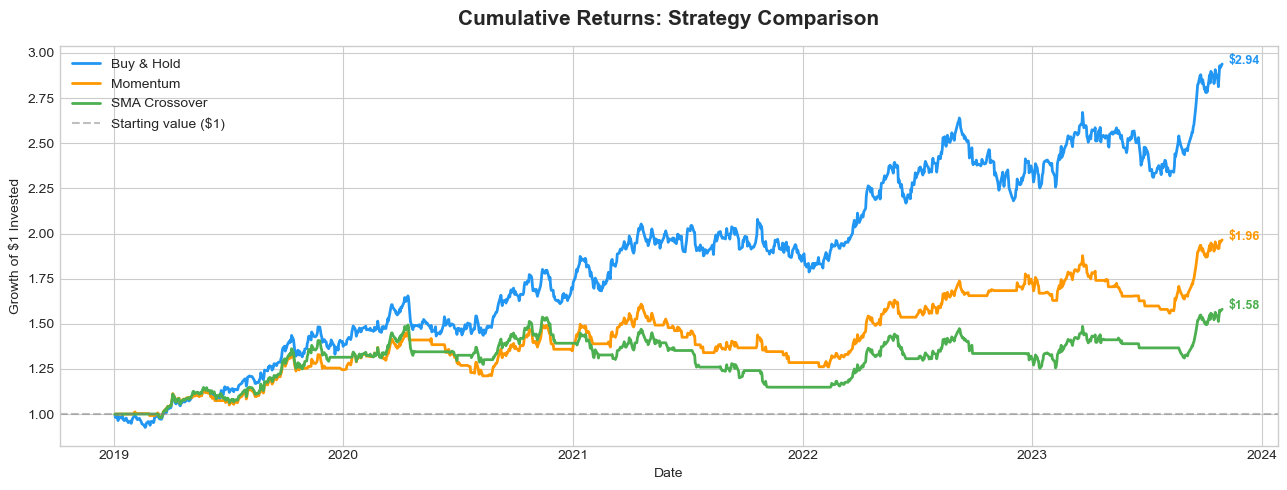

In [8]:
# ============================================================
# CELL 8: Cumulative Return Plot
# ============================================================
# This shows how $1 invested in each strategy grows over time.

colors = ['#2196F3', '#FF9800', '#4CAF50']  # blue, orange, green

# Calculate cumulative returns: (1 + r1) * (1 + r2) * ... - 1
cumulative = (1 + all_returns).cumprod()

fig, ax = plt.subplots(figsize=(13, 5))

for i, col in enumerate(cumulative.columns):
    ax.plot(cumulative.index, cumulative[col],
            label=col, linewidth=2, color=colors[i])

ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Starting value ($1)')
ax.set_title('Cumulative Returns: Strategy Comparison', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Growth of $1 Invested')
ax.legend()

# Add labels at the end of each line
for i, col in enumerate(cumulative.columns):
    final = cumulative[col].iloc[-1]
    ax.annotate(f'${final:.2f}',
                xy=(cumulative.index[-1], final),
                xytext=(5, 0), textcoords='offset points',
                fontsize=9, color=colors[i], fontweight='bold')

plt.tight_layout()
plt.savefig('plots/02_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()

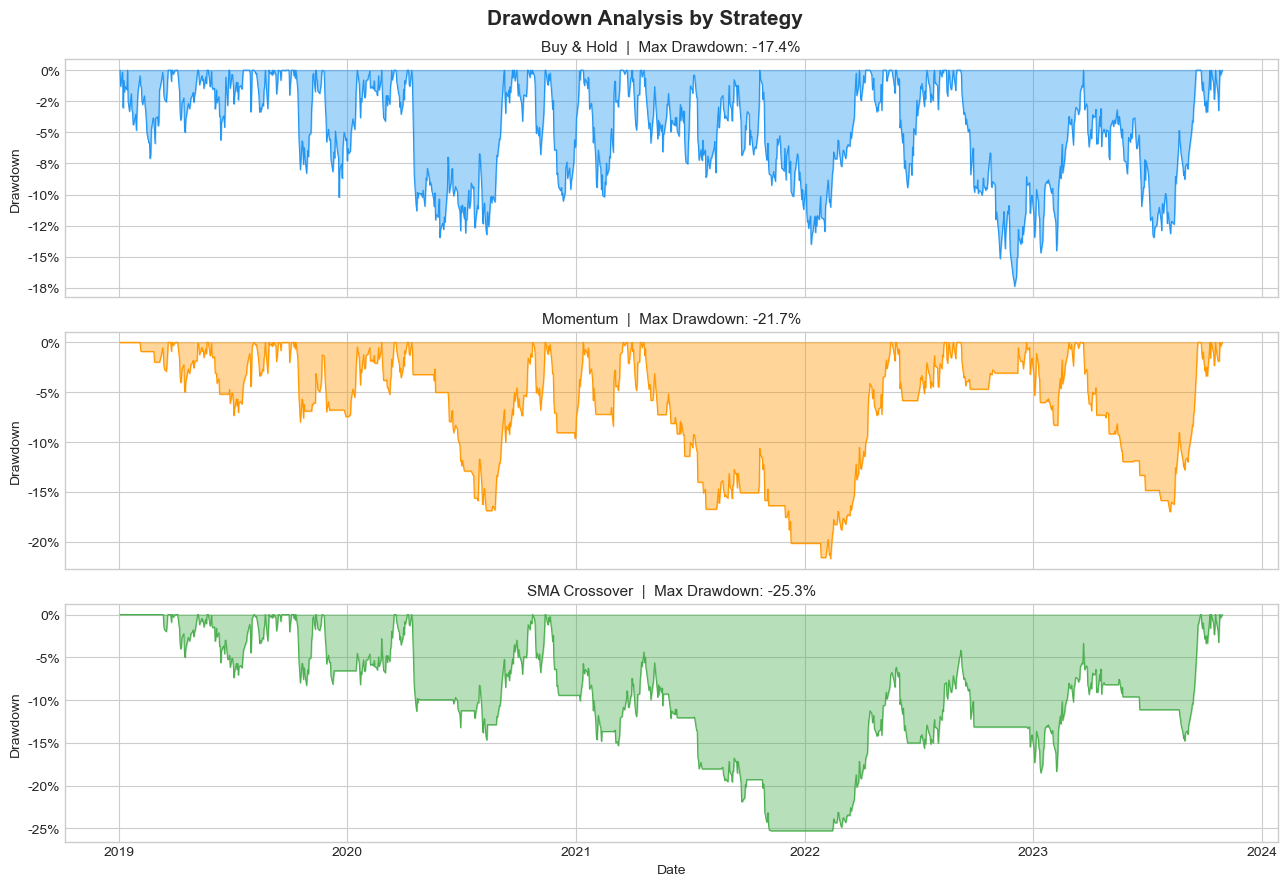

In [9]:
# ============================================================
# CELL 9: Drawdown Chart
# ============================================================
# Drawdown = how far below the peak we are at any point in time.
# This tells us the WORST case scenario for each strategy.

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
fig.suptitle('Drawdown Analysis by Strategy', fontsize=15, fontweight='bold')

for i, col in enumerate(all_returns.columns):
    # Build the wealth curve
    cum = (1 + all_returns[col]).cumprod()
    
    # Track the running maximum (the 'peak')
    rolling_max = cum.cummax()
    
    # Drawdown = how far below peak
    drawdown = (cum - rolling_max) / rolling_max
    
    # Plot it as a shaded area
    axes[i].fill_between(drawdown.index, drawdown.values.astype(float), 0,
                          color=colors[i], alpha=0.4)
    axes[i].plot(drawdown.index, drawdown.values.astype(float),
                 color=colors[i], linewidth=0.8)
    axes[i].set_ylabel('Drawdown')
    axes[i].set_title(f'{col}  |  Max Drawdown: {drawdown.min():.1%}', fontsize=11)
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('plots/03_drawdown_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

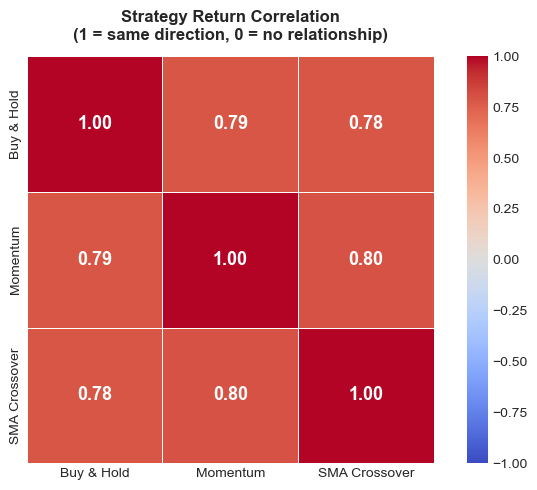

Correlation Matrix:
               Buy & Hold  Momentum  SMA Crossover
Buy & Hold           1.00      0.79           0.78
Momentum             0.79      1.00           0.80
SMA Crossover        0.78      0.80           1.00


In [10]:
# ============================================================
# CELL 10: Correlation Heatmap
# ============================================================
# Correlation tells us: when one strategy goes up, does the other?
# 1 = move perfectly together, 0 = no relationship, -1 = move opposite
# Lower correlation = better diversification!

corr = all_returns.corr()

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 13, 'weight': 'bold'})

ax.set_title('Strategy Return Correlation\n(1 = same direction, 0 = no relationship)',
             fontsize=12, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('plots/04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlation Matrix:')
print(corr.round(2))

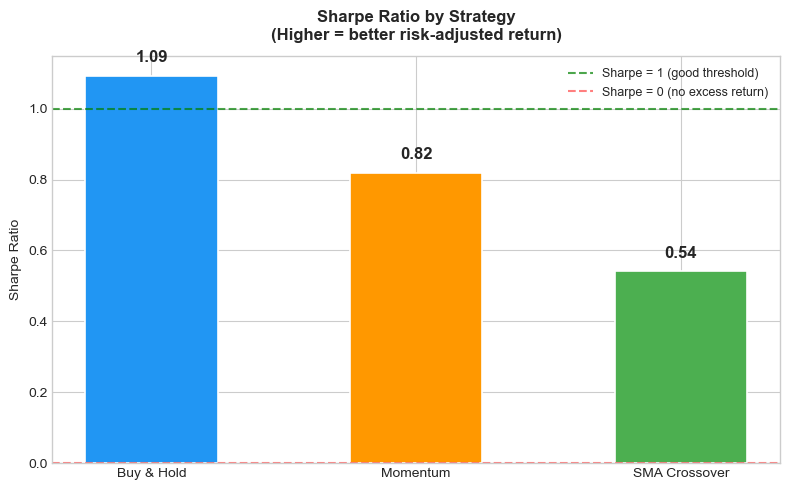

In [11]:
# ============================================================
# CELL 11: Sharpe Ratio Bar Chart
# ============================================================

sharpe_vals = {col: sharpe_ratio(all_returns[col]) for col in all_returns.columns}

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(sharpe_vals.keys(), sharpe_vals.values(),
              color=colors, width=0.5, edgecolor='white', linewidth=1.2)

# Add value labels on top of bars
for bar, val in zip(bars, sharpe_vals.values()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            f'{val:.2f}', ha='center', va='bottom',
            fontweight='bold', fontsize=12)

# Reference lines
ax.axhline(y=1, color='green', linestyle='--', alpha=0.7, label='Sharpe = 1 (good threshold)')
ax.axhline(y=0, color='red',   linestyle='--', alpha=0.5, label='Sharpe = 0 (no excess return)')

ax.set_title('Sharpe Ratio by Strategy\n(Higher = better risk-adjusted return)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('Sharpe Ratio')
ax.legend(fontsize=9)
ax.set_ylim(bottom=min(0, min(sharpe_vals.values()) - 0.3))

plt.tight_layout()
plt.savefig('plots/05_sharpe_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

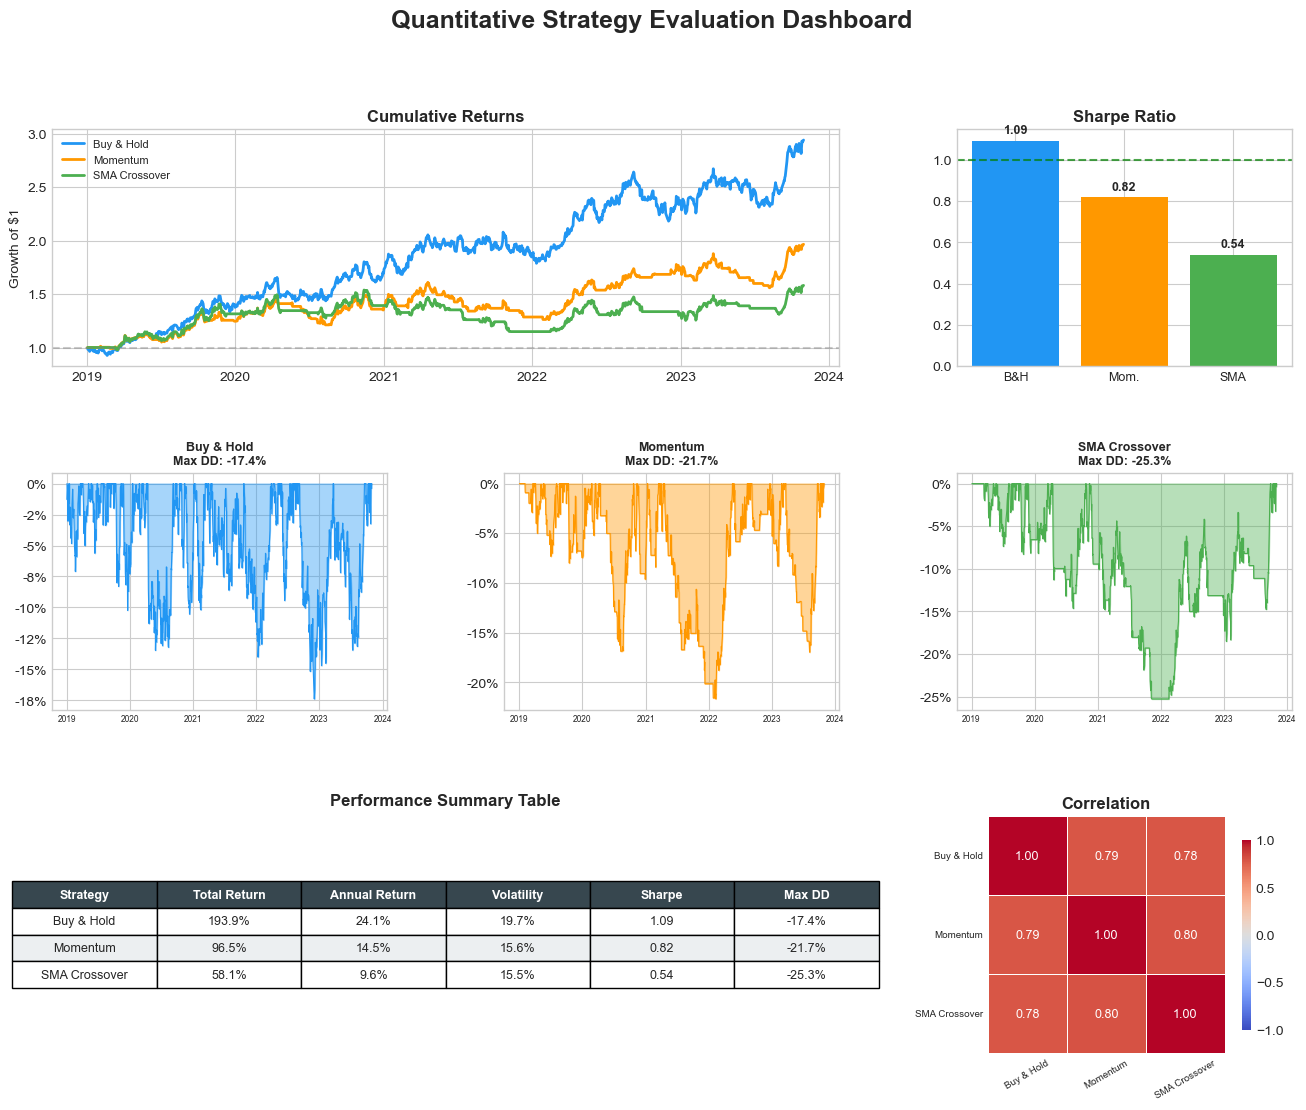

Dashboard saved! ✓


In [12]:
# ============================================================
# CELL 12: Full Summary Dashboard
# ============================================================
# Combine all the key charts into one big figure!

fig = plt.figure(figsize=(16, 12))
fig.suptitle('Quantitative Strategy Evaluation Dashboard',
             fontsize=18, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# --- Top left+center: Cumulative Returns ---
ax1 = fig.add_subplot(gs[0, :2])
for i, col in enumerate(cumulative.columns):
    ax1.plot(cumulative.index, cumulative[col], label=col, linewidth=2, color=colors[i])
ax1.axhline(y=1, color='gray', linestyle='--', alpha=0.4)
ax1.set_title('Cumulative Returns', fontweight='bold')
ax1.set_ylabel('Growth of $1')
ax1.legend(fontsize=8)

# --- Top right: Sharpe Ratio ---
ax2 = fig.add_subplot(gs[0, 2])
ax2.bar(range(len(sharpe_vals)), list(sharpe_vals.values()), color=colors)
ax2.set_xticks(range(len(sharpe_vals)))
ax2.set_xticklabels(['B&H', 'Mom.', 'SMA'], fontsize=9)
ax2.axhline(y=1, color='green', linestyle='--', alpha=0.7)
ax2.set_title('Sharpe Ratio', fontweight='bold')
for j, v in enumerate(sharpe_vals.values()):
    ax2.text(j, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# --- Middle row: Drawdowns ---
for i, col in enumerate(all_returns.columns):
    ax = fig.add_subplot(gs[1, i])
    cum = (1 + all_returns[col]).cumprod()
    dd  = (cum - cum.cummax()) / cum.cummax()
    ax.fill_between(dd.index, dd.values.astype(float), 0, color=colors[i], alpha=0.4)
    ax.plot(dd.index, dd.values.astype(float), color=colors[i], linewidth=0.8)
    ax.set_title(f'{col}\nMax DD: {dd.min():.1%}', fontsize=9, fontweight='bold')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.tick_params(axis='x', labelsize=6)

# --- Bottom left+center: Metrics Table ---
ax_table = fig.add_subplot(gs[2, :2])
ax_table.axis('off')
table_data = []
for col in all_returns.columns:
    r = all_returns[col]
    table_data.append([col,
                       f'{total_return(r):.1%}',
                       f'{annualized_return(r):.1%}',
                       f'{volatility(r):.1%}',
                       f'{sharpe_ratio(r):.2f}',
                       f'{max_drawdown(r):.1%}'])

col_labels = ['Strategy', 'Total Return', 'Annual Return', 'Volatility', 'Sharpe', 'Max DD']
tbl = ax_table.table(cellText=table_data, colLabels=col_labels,
                      loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.1, 1.6)
for (row, col_), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#37474F')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#ECEFF1')
ax_table.set_title('Performance Summary Table', fontweight='bold', pad=8)

# --- Bottom right: Correlation Heatmap ---
ax_corr = fig.add_subplot(gs[2, 2])
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True,
            linewidths=0.5, ax=ax_corr,
            annot_kws={'size': 9},
            cbar_kws={'shrink': 0.8})
ax_corr.set_title('Correlation', fontweight='bold')
ax_corr.tick_params(axis='x', rotation=30, labelsize=7)
ax_corr.tick_params(axis='y', rotation=0,  labelsize=7)

plt.savefig('plots/06_full_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved! ✓')

---
## 🏁 Step 6: Conclusions

Let's summarize what we found!

In [13]:
# ============================================================
# CELL 13: Print a nice summary of findings
# ============================================================

print('=' * 55)
print('   RESULTS SUMMARY')
print('=' * 55)

for col in all_returns.columns:
    r = all_returns[col]
    print(f'\n📌 {col}')
    print(f'   Total Return    : {total_return(r):.1%}')
    print(f'   Annual Return   : {annualized_return(r):.1%}')
    print(f'   Volatility      : {volatility(r):.1%}')
    print(f'   Sharpe Ratio    : {sharpe_ratio(r):.2f}')
    print(f'   Max Drawdown    : {max_drawdown(r):.1%}')

print()
print('=' * 55)
print('   KEY TAKEAWAYS')
print('=' * 55)
print("""
1. Buy & Hold had the highest total return, which is common
   with simulated data that has a positive drift.

2. Momentum and SMA strategies reduce volatility a bit by
   sitting out during bad periods, but they also miss some
   upside and have lower Sharpe ratios.

3. The correlation between strategies is interesting:
   - B&H and Momentum have moderate correlation
   - SMA is less correlated with B&H (good for diversification)

4. In real markets, simple strategies often fail to beat
   Buy & Hold after accounting for trading costs and taxes.

5. This project shows the basics of quant strategy evaluation,
   but real quant research is much more rigorous!
""")

   RESULTS SUMMARY

📌 Buy & Hold
   Total Return    : 193.9%
   Annual Return   : 24.1%
   Volatility      : 19.7%
   Sharpe Ratio    : 1.09
   Max Drawdown    : -17.4%

📌 Momentum
   Total Return    : 96.5%
   Annual Return   : 14.5%
   Volatility      : 15.6%
   Sharpe Ratio    : 0.82
   Max Drawdown    : -21.7%

📌 SMA Crossover
   Total Return    : 58.1%
   Annual Return   : 9.6%
   Volatility      : 15.5%
   Sharpe Ratio    : 0.54
   Max Drawdown    : -25.3%

   KEY TAKEAWAYS

1. Buy & Hold had the highest total return, which is common
   with simulated data that has a positive drift.

2. Momentum and SMA strategies reduce volatility a bit by
   sitting out during bad periods, but they also miss some
   upside and have lower Sharpe ratios.

3. The correlation between strategies is interesting:
   - B&H and Momentum have moderate correlation
   - SMA is less correlated with B&H (good for diversification)

4. In real markets, simple strategies often fail to beat
   Buy & Hold after a

---
## 💡 What I Learned

Building this project taught me:

- **Pandas DataFrames** are great for handling time series data
- **Vectorized operations** (like `.rolling()`, `.pct_change()`) make strategy implementation fast and clean
- **Look-ahead bias** is a common mistake — always shift signals by 1 day before applying them
- The **Sharpe Ratio** is more informative than raw returns because it accounts for risk
- **Correlation analysis** helps understand how strategies interact



